## Problem 1

In [1]:
# symbolic computation tools
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve, minimize
from sympy import init_printing
init_printing() 

def cross_matrix(vec):
    return np.matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    return np.matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    return(m)

def inv(T):
    T_0_inv = Matrix.zeros(4,4)
    T_0_inv[0:3, 0:3] = T[0:3,0:3].T
    T_0_inv[0:3, 3] = -T[0:3,0:3].T @ T[0:3,3]
    T_0_inv[3, 3] = 1
    return T_0_inv
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])
    
def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m
    
def plot_transform(T, ax):
    origin = T[0:3, 3]
    sc = 0.5
    
    ax.plot([origin[0], sc*T[0,0]+origin[0]], 
            [origin[1], sc*T[1,0]+origin[1]], 
            [origin[2], sc*T[2,0]+origin[2]], 
            color='red', linestyle='-', marker='o', linewidth=5)
    ax.plot([origin[0], sc*T[0,1]+origin[0]], 
            [origin[1], sc*T[1,1]+origin[1]], 
            [origin[2], sc*T[2,1]+origin[2]], 
            color='green', linestyle='-', marker='o', linewidth=5)
    # ax.plot([origin[0], T[0,2]+origin[0]], 
    #         [origin[1], T[1,2]+origin[1]], 
    #         [origin[2], T[2,2]+origin[2]], 
    #         color='blue', linestyle='-', marker='o', linewidth=5)
    
    
def plot_bot(Tb, T1, T2, w_, ax):
    plot_transform(T(eye(3), Matrix([[0], [0], [0]])), ax)

    plot_transform(Tb, ax)
    plot_transform(T1, ax)
    plot_transform(T2, ax)
    
    j1 = Tb @ T(eye(3), Matrix([[-w_], [0], [0]]))
    j2 = Tb @ T(eye(3), Matrix([[w_], [0], [0]]))
    e1 = T1 @ T(eye(3), Matrix([[w_], [0], [0]]))
    e2 = T2 @ T(eye(3), Matrix([[w_], [0], [0]]))
    
    ax.plot([Tb[0,3], j1[0,3]], [Tb[1,3], j1[1,3]], 'ko-', markersize = 8)
    ax.plot([Tb[0,3], j2[0,3]], [Tb[1,3], j2[1,3]], 'ko-', markersize = 8)
    
    ax.plot([j1[0,3], T1[0,3]], [j1[1,3], T1[1,3]], 'ko-')
    ax.plot([j2[0,3], T2[0,3]], [j2[1,3], T2[1,3]], 'ko-')
    
    ax.plot([e1[0,3], T1[0,3]], [e1[1,3], T1[1,3]], 'ko-')
    ax.plot([e2[0,3], T2[0,3]], [e2[1,3], T2[1,3]], 'ko-')
    

### Configuration

In [2]:
##### Geometry
t = symbols("t" , real = True)
l = symbols("l" , real = True)
d = symbols("d", real = True)
k = symbols("k", real = True)

##### Configuration variables
alpha1 = Function('alpha1', real=True)(t)
alpha2 = Function('alpha2', real=True)(t)
x = Function('x', real=True)(t)
y = Function('y', real=True)(t)
theta = Function('theta', real=True)(t)

##### Alpha kinematics variabls
omega = symbols("omega" , real = True)
A1 = symbols("A1" , real = True)
A2 = symbols("A2" , real = True)
phi = symbols("phi" , real = True)


### Transformations, Body Twists, and Jacobians

In [3]:
q = [x, y, theta, alpha1, alpha2]
q_dt = [sp.diff(qq, t) for qq in q]
q_dtdt = [sp.diff(qq, t, t) for qq in q]

T_0b = T(R_z(theta), Matrix([[x], [y], [0]]))

# Left link 1 COM
T_l1 = (T_0b
        @ T(eye(3),       Matrix([[l/2], [0], [0]]))
        @ T(R_z(alpha1), Matrix([[0],   [0], [0]]))
        @ T(eye(3),       Matrix([[d/2], [0], [0]])))

# Left link 2 COM
T_l2 = (T_0b
        @ T(eye(3),       Matrix([[l/2], [0], [0]]))
        @ T(R_z(alpha1), Matrix([[0],   [0], [0]]))
        @ T(eye(3),       Matrix([[d],   [0], [0]]))
        @ T(R_z(alpha2), Matrix([[0],   [0], [0]]))
        @ T(eye(3),       Matrix([[d/2], [0], [0]])))

# Right link 1 COM
T_r1 = (T_0b
        @ T(eye(3),        Matrix([[l/2], [0], [0]]))
        @ T(R_z(-alpha1), Matrix([[0],   [0], [0]]))
        @ T(eye(3),        Matrix([[d/2], [0], [0]])))

# Right link 2 COM
T_r2 = (T_0b
        @ T(eye(3),        Matrix([[l/2], [0], [0]]))
        @ T(R_z(-alpha1), Matrix([[0],   [0], [0]]))
        @ T(eye(3),        Matrix([[d],   [0], [0]]))
        @ T(R_z(-alpha2), Matrix([[0],   [0], [0]]))
        @ T(eye(3),        Matrix([[d/2], [0], [0]])))
# Body twists
# Vb = T^-1 * Tdot
body_twist_b = T_0b.inv() @ sp.diff(T_0b, t)
body_twist_l1 = T_l1.inv() @ sp.diff(T_l1, t)
body_twist_l2 = T_l2.inv() @ sp.diff(T_l2, t)
body_twist_r1 = T_r1.inv() @ sp.diff(T_r1, t)
body_twist_r2 = T_r2.inv() @ sp.diff(T_r2, t)

# Twist vectors
v_b = twist2vec(body_twist_b)
v_l1 = twist2vec(body_twist_l1)
v_l2 = twist2vec(body_twist_l2)
v_r1 = twist2vec(body_twist_r1)
v_r2 = twist2vec(body_twist_r2)

# Body Jacobians
J_b = v_b.jacobian(q_dt)
J_l1 = v_l1.jacobian(q_dt)
J_l2 = v_l2.jacobian(q_dt)
J_r1 = v_r1.jacobian(q_dt)
J_r2 = v_r2.jacobian(q_dt)


# Drag matrices
# Body drag matrix, body length L
B_body = -Matrix([
    [0, 0, 0,              0,   0,      0],
    [0, 0, 0,              0,   0,      0],
    [0, 0, 2/3*k*l**3,     0,   0,      0],
    [0, 0, 0,              k*l, 0,      0],
    [0, 0, 0,              0,   2*k*l,  0],
    [0, 0, 0,              0,   0,      0]
])

# Appendage link drag matrix, link length d
B_link = -Matrix([
    [0, 0, 0,              0,   0,      0],
    [0, 0, 0,              0,   0,      0],
    [0, 0, 2/3*k*d**3,     0,   0,      0],
    [0, 0, 0,              k*d, 0,      0],
    [0, 0, 0,              0,   2*k*d,  0],
    [0, 0, 0,              0,   0,      0]
])

# Generalized force balance matrix
A = J_b.T  @ B_body @ J_b + J_l1.T @ B_link @ J_l1 + J_l2.T @ B_link @ J_l2 + J_r1.T @ B_link @ J_r1 + J_r2.T @ B_link @ J_r2

A_11 = A[0:3, 0:3]
A_12 = A[0:3, 3:]
A_21 = A[3:, 0:3]
A_22 = A[3:, 3:]

# Local connection matrix
# pose_dot = -A_11^-1 A_12 shape_dot
A_tilde = -A_11.LUsolve(A_12)


In [4]:
params_sym = [l, d, k]
A_tilde_lambda = lambdify([q, params_sym], A_tilde, "numpy")

params = [l, d, k, A1, A2, omega, phi]
A_11_lambda       =   lambdify([t, q, q_dt, params], A_11)
A_12_lambda       =   lambdify([t, q, q_dt, params], A_12)


### Part 2 Foruier Function and Plotting Hand Design

In [5]:
def fourier_gate(coefficients, t, params):
    l, d, k, A1, A2, omega, phi = params

    alpha1 = A1 * np.sin(omega * t)
    alpha2 = A2 * np.sin(omega * t + phi)

    alpha_1_dot = A1 * omega * np.cos(omega * t)
    alpha_2_dot = A2 * omega * np.cos(omega * t + phi)

    return alpha1, alpha2, alpha_1_dot, alpha_2_dot

In [6]:
def dynamics(t, state, params, coefficients):
    x, y, theta = state
    
    a1, a2, a1_dt, a2_dt = fourier_gate(coefficients, t, params)
    
    q_num = np.array([x, y, theta, a1, a2], dtype=float)
    
    A_tilde_num = np.array(A_tilde_lambda(q_num, params[:3]), dtype=float)  # just q and [l,d,k]
    
    shape_dot = np.array([[a1_dt], [a2_dt]])
    
    return (A_tilde_num @ shape_dot).flatten().tolist()

In [7]:
def gait_cycle(coefficients, params, T=2*np.pi):
    omega = params[5]                                    # index 5, not 6
    T = 2 * np.pi / omega if omega != 0 else T
    
    state0 = [0.0, 0.0, 0.0]
    
    sol = solve_ivp(
        dynamics,
        [0, T],
        state0,
        args=(params, coefficients),
        dense_output=True,
        max_step=T / 200
    )
    
    time = sol.t
    x_sol     = sol.y[0]
    y_sol     = sol.y[1]
    theta_sol = sol.y[2]
    
    alpha_1_sol     = np.zeros(len(time))
    alpha_2_sol     = np.zeros(len(time))
    alpha_1_dot_sol = np.zeros(len(time))
    alpha_2_dot_sol = np.zeros(len(time))
    
    for i, ti in enumerate(time):
        a1, a2, a1d, a2d = fourier_gate(coefficients, ti, params)
        alpha_1_sol[i]     = a1
        alpha_2_sol[i]     = a2
        alpha_1_dot_sol[i] = a1d
        alpha_2_dot_sol[i] = a2d
    
    x_dot_sol     = np.zeros(len(time))
    y_dot_sol     = np.zeros(len(time))
    theta_dot_sol = np.zeros(len(time))
    
    for i, ti in enumerate(time):
        dstate = dynamics(ti, sol.y[:, i], params, coefficients)
        x_dot_sol[i]     = dstate[0]
        y_dot_sol[i]     = dstate[1]
        theta_dot_sol[i] = dstate[2]

    return time, x_sol, y_sol, theta_sol, alpha_1_sol, alpha_2_sol, \
           x_dot_sol, y_dot_sol, theta_dot_sol, alpha_1_dot_sol, alpha_2_dot_sol

### Hand Gait Cycle Plot

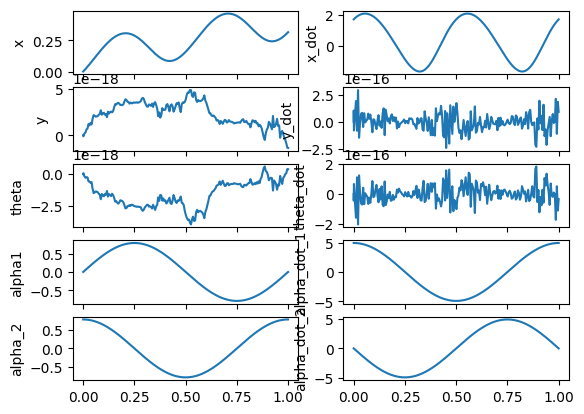

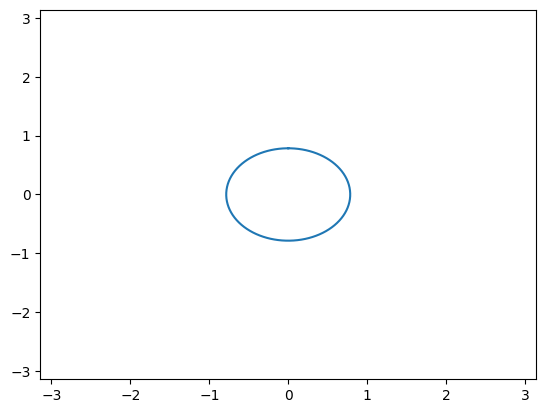

In [8]:
l_ = 2
d_ = 1
k_ = 1
A1_ = np.pi/4    # nonzero so the gait actually drives motion
A2_ = np.pi/4
omega_ = 2*np.pi
phi_ = np.pi/2
params_ = [l_, d_, k_, A1_, A2_, omega_, phi_]
coefficients = [1, 0, 0, 1, .5, .5, .5, .5]

time, x_sol, y_sol, theta_sol, alpha_1_sol, alpha_2_sol, \
x_dot_sol, y_dot_sol, theta_dot_sol, alpha_1_dot_sol, alpha_2_dot_sol = gait_cycle(coefficients, params_)
fig = plt.figure(1)
fig.clf()
ax = fig.subplots(5, 2, sharex = True)

ax[0][0].plot(time, x_sol)
ax[0][0].set_ylabel('x')
ax[1][0].plot(time, y_sol)
ax[1][0].set_ylabel('y')
ax[2][0].plot(time, theta_sol)
ax[2][0].set_ylabel('theta')
ax[3][0].plot(time, alpha_1_sol)
ax[3][0].set_ylabel('alpha1')
ax[4][0].plot(time, alpha_2_sol)
ax[4][0].set_ylabel('alpha_2')

ax[0][1].plot(time, x_dot_sol)
ax[0][1].set_ylabel('x_dot')
ax[1][1].plot(time, y_dot_sol)
ax[1][1].set_ylabel('y_dot')
ax[2][1].plot(time, theta_dot_sol)
ax[2][1].set_ylabel('theta_dot')
ax[3][1].plot(time, alpha_1_dot_sol)
ax[3][1].set_ylabel('alpha_dot_1')
ax[4][1].plot(time, alpha_2_dot_sol)
ax[4][1].set_ylabel('alpha_dot_2')
# plt.gcf()
plt.figure(10)

plt.plot(alpha_1_sol, alpha_2_sol)
plt.gca().axis([-np.pi, np.pi, -np.pi, np.pi])

### Part 3 Gait Optimization

Optimizing forward distance...
Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.548316058433243
            Iterations: 8
            Function evaluations: 56
            Gradient evaluations: 8
Max forward distance: 0.5483

Optimizing cost of transport...
Optimization terminated successfully    (Exit mode 0)
            Current function value: 38.839324974625846
            Iterations: 33
            Function evaluations: 305
            Gradient evaluations: 32
Min cost of transport: 38.8393

Max Distance | Distance = +0.5483 | CoT = 109.4406


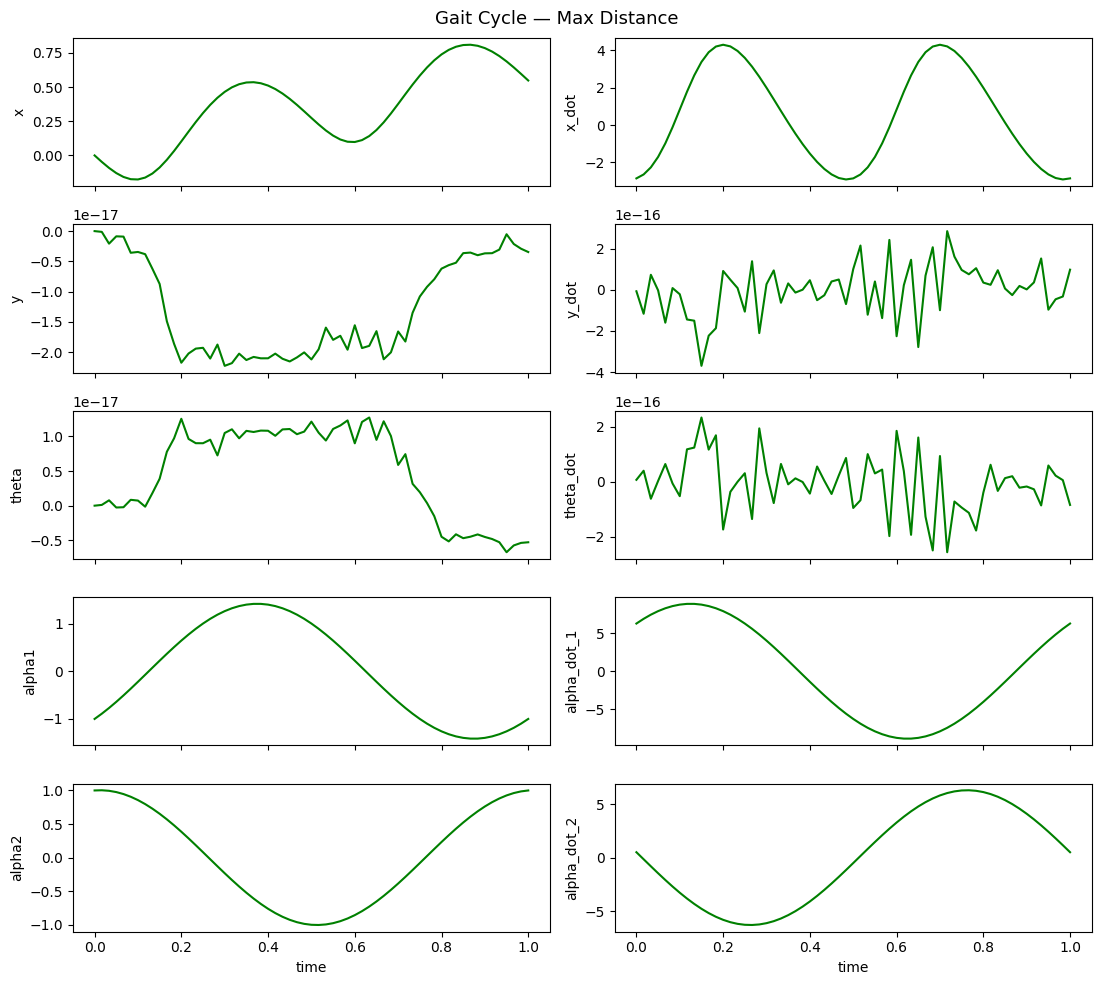

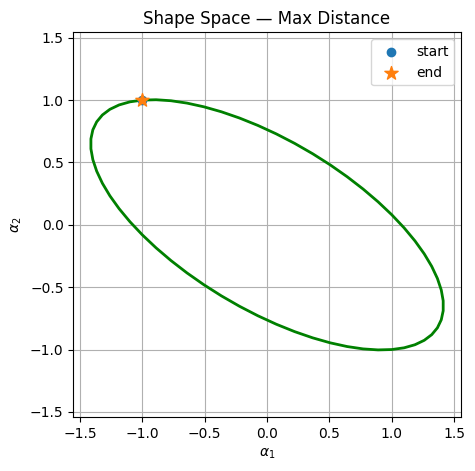


Min CoT | Distance = +0.0100 | CoT = 38.8393


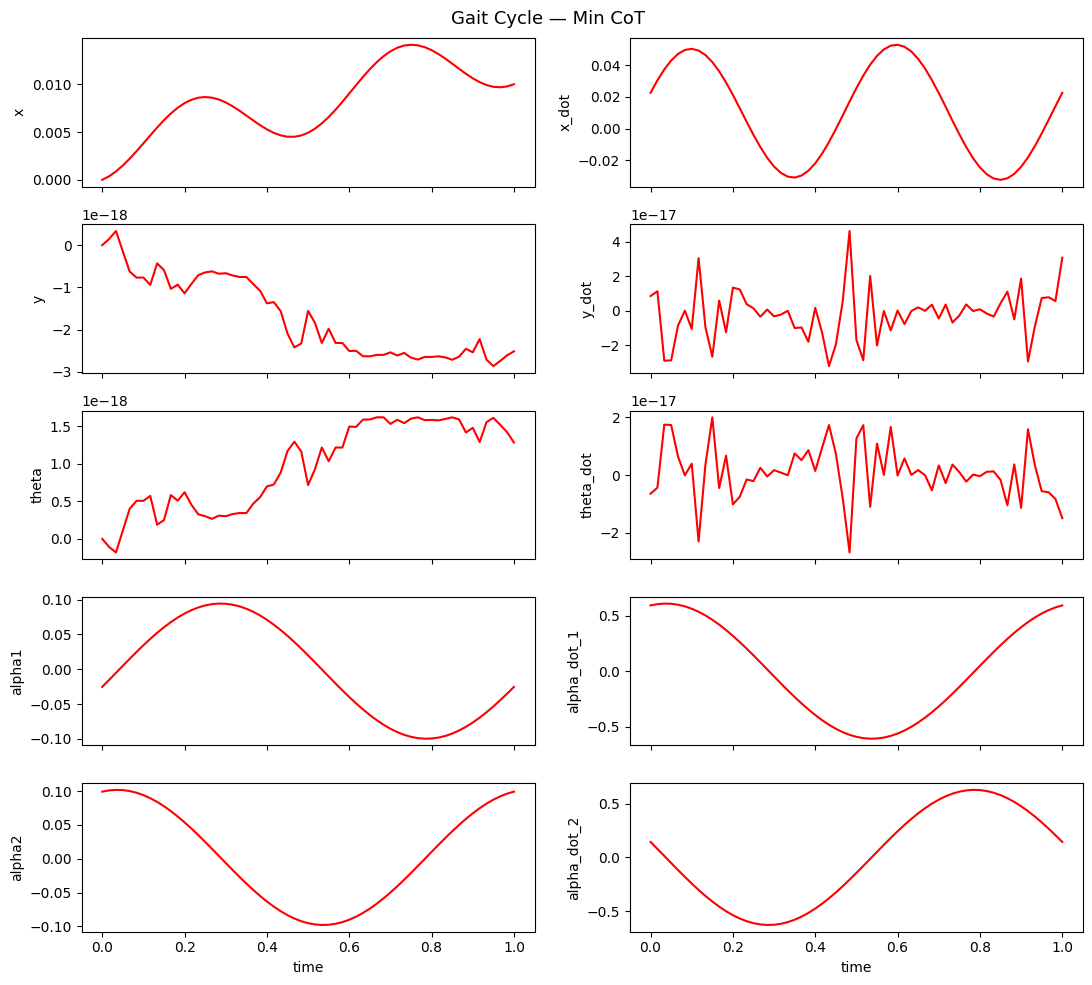

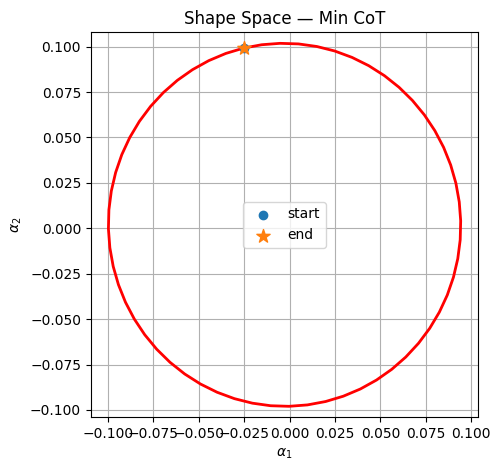

In [13]:
l_ = 2
d_ = 1
k_ = 1
omega_ = 2*np.pi
params_opt = [l_, d_, k_]
dt = 1/60
z0 = np.array([0.0, 0.0, 0.0])

# Fourier gait with offsets — matches friend's structure
def fourier_gate_with_offset(t, c, omega=2*np.pi):
    a1_off, a2_off = c[0], c[1]
    a1_cos, a1_sin = c[2], c[3]
    a2_cos, a2_sin = c[4], c[5]

    alpha1 = a1_off + a1_cos*np.cos(omega*t) + a1_sin*np.sin(omega*t)
    alpha2 = a2_off + a2_cos*np.cos(omega*t) + a2_sin*np.sin(omega*t)

    alpha1_dot = -a1_cos*omega*np.sin(omega*t) + a1_sin*omega*np.cos(omega*t)
    alpha2_dot = -a2_cos*omega*np.sin(omega*t) + a2_sin*omega*np.cos(omega*t)

    return alpha1, alpha2, alpha1_dot, alpha2_dot

# Swimmer dynamics
def swimmer_dynamics(t, z, c):
    x_num, y_num, theta_num = z

    alpha1, alpha2, alpha1_dot, alpha2_dot = fourier_gate_with_offset(t, c)

    q_num = np.array([x_num, y_num, theta_num, alpha1, alpha2], dtype=float)

    A_tilde_num = np.array(A_tilde_lambda(q_num, params_opt), dtype=float)

    shape_dot = np.array([alpha1_dot, alpha2_dot], dtype=float)

    return (A_tilde_num @ shape_dot).flatten()

# Fast Euler simulation — same structure as friend's simulate_one_cycle
def simulate_one_cycle(c, dt=1/60):
    z = z0.copy()
    time_hist = np.arange(0.0, 1.0 + dt, dt)

    x_hist, y_hist, theta_hist         = [], [], []
    a1_hist, a2_hist                   = [], []
    a1d_hist, a2d_hist                 = [], []
    xd_hist, yd_hist, td_hist          = [], [], []

    for ti in time_hist:
        alpha1, alpha2, alpha1_dot, alpha2_dot = fourier_gate_with_offset(ti, c)
        zdot = swimmer_dynamics(ti, z, c)

        x_hist.append(z[0]);   y_hist.append(z[1]);   theta_hist.append(z[2])
        a1_hist.append(alpha1); a2_hist.append(alpha2)
        a1d_hist.append(alpha1_dot); a2d_hist.append(alpha2_dot)
        xd_hist.append(zdot[0]); yd_hist.append(zdot[1]); td_hist.append(zdot[2])

        z = z + dt * zdot
        if not np.all(np.isfinite(z)):
            break

    n = len(x_hist)
    return {
        "time":      np.array(time_hist[:n]),
        "x":         np.array(x_hist),
        "y":         np.array(y_hist),
        "theta":     np.array(theta_hist),
        "alpha1":    np.array(a1_hist),
        "alpha2":    np.array(a2_hist),
        "alpha1_dot":np.array(a1d_hist),
        "alpha2_dot":np.array(a2d_hist),
        "x_dot":     np.array(xd_hist),
        "y_dot":     np.array(yd_hist),
        "theta_dot": np.array(td_hist),
    }

# --- Objective: maximize forward distance ---
def objective_max_dist(c):
    try:
        sim = simulate_one_cycle(c, dt=dt)
        if len(sim["x"]) < 5:
            return 1e6
        net_x = sim["x"][-1] - sim["x"][0]
        if not np.isfinite(net_x):
            return 1e6
        return -net_x
    except:
        return 1e6

# --- Objective: minimize cost of transport ---
def objective_min_COT(c):
    try:
        sim = simulate_one_cycle(c, dt=dt)
        if len(sim["x"]) < 5:
            return 1e6
        net_x = sim["x"][-1] - sim["x"][0]
        if net_x <= 0.01:
            return 1e6
        effort = dt * np.sum(sim["alpha1_dot"]**2 + sim["alpha2_dot"]**2)
        COT = effort / net_x
        if not np.isfinite(COT) or COT > 200:
            return 1e6
        return COT
    except:
        return 1e6

# Initial guess — hand gait: alpha1=pi/4*sin, alpha2=pi/4*cos
# c = [a1_off, a2_off, a1_cos, a1_sin, a2_cos, a2_sin]
c0 = np.array([0.0, 0.0, 0.0, np.pi/4, np.pi/4, 0.0])

bounds = [
    (-0.5, 0.5),   # a1 offset
    (-0.5, 0.5),   # a2 offset
    (-1.0, 1.0),   # a1 cos
    (-1.0, 1.0),   # a1 sin
    (-1.0, 1.0),   # a2 cos
    (-1.0, 1.0),   # a2 sin
]

# --- Optimization 1: Maximize forward distance ---
print("Optimizing forward distance...")
result_dist = minimize(
    objective_max_dist, c0,
    method='SLSQP', bounds=bounds,
    options={'maxiter': 50, 'ftol': 1e-4, 'disp': True}
)
c_opt_dist = result_dist.x
print(f"Max forward distance: {-result_dist.fun:.4f}")

# --- Optimization 2: Minimize cost of transport ---
print("\nOptimizing cost of transport...")
result_cot = minimize(
    objective_min_COT, c0,
    method='SLSQP', bounds=bounds,
    options={'maxiter': 50, 'ftol': 1e-4, 'disp': True}
)
c_opt_cot = result_cot.x
print(f"Min cost of transport: {result_cot.fun:.4f}")

# --- Simulate and plot optimized gaits ---
for c, label, col in zip(
    [c_opt_dist,     c_opt_cot],
    ['Max Distance', 'Min CoT'],
    ['green',        'red']
):
    sim = simulate_one_cycle(c, dt=dt)

    time  = sim["time"]
    x     = sim["x"];     y     = sim["y"];     theta = sim["theta"]
    a1    = sim["alpha1"]; a2   = sim["alpha2"]
    a1d   = sim["alpha1_dot"]; a2d = sim["alpha2_dot"]
    xd    = sim["x_dot"]; yd   = sim["y_dot"]; td   = sim["theta_dot"]

    effort   = dt * np.sum(a1d**2 + a2d**2)
    distance = x[-1] - x[0]
    cot      = effort / distance if abs(distance) > 1e-6 else np.inf

    print(f"\n{label} | Distance = {distance:+.4f} | CoT = {cot:.4f}")

    # Gait cycle plot
    fig = plt.figure(figsize=(11, 10))
    fig.suptitle(f"Gait Cycle — {label}", fontsize=13)
    ax = fig.subplots(5, 2, sharex=True)

    ax[0][0].plot(time, x,     color=col); ax[0][0].set_ylabel('x')
    ax[1][0].plot(time, y,     color=col); ax[1][0].set_ylabel('y')
    ax[2][0].plot(time, theta, color=col); ax[2][0].set_ylabel('theta')
    ax[3][0].plot(time, a1,    color=col); ax[3][0].set_ylabel('alpha1')
    ax[4][0].plot(time, a2,    color=col); ax[4][0].set_ylabel('alpha2')
    ax[4][0].set_xlabel('time')

    ax[0][1].plot(time, xd,  color=col); ax[0][1].set_ylabel('x_dot')
    ax[1][1].plot(time, yd,  color=col); ax[1][1].set_ylabel('y_dot')
    ax[2][1].plot(time, td,  color=col); ax[2][1].set_ylabel('theta_dot')
    ax[3][1].plot(time, a1d, color=col); ax[3][1].set_ylabel('alpha_dot_1')
    ax[4][1].plot(time, a2d, color=col); ax[4][1].set_ylabel('alpha_dot_2')
    ax[4][1].set_xlabel('time')

    plt.tight_layout()
    plt.show()

    # Shape space plot
    plt.figure(figsize=(5, 5))
    plt.plot(a1, a2, color=col, lw=2)
    plt.scatter(a1[0], a2[0], label='start', zorder=5)
    plt.scatter(a1[-1], a2[-1], label='end', marker='*', s=100, zorder=5)
    plt.xlabel(r'$\alpha_1$'); plt.ylabel(r'$\alpha_2$')
    plt.title(f'Shape Space — {label}')
    plt.axis('equal'); plt.grid(True); plt.legend()
    plt.show()